# Sequence-to-Sequence Models with Attention for Machine Translation

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand sequence-to-sequence (seq2seq) encoder–decoder architectures
- **Build a real Keras seq2seq model with attention**, layer by layer, and inspect its structure
- Run a forward pass through the (untrained) model and verify the tensor shapes
- Understand what attention adds to seq2seq, and what actually *training* this model would require

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 4, lessons 01-02 (attention, and RNN hidden states) — an encoder-decoder is two RNNs joined by an attention bridge.

**Used later in:** Course 08 (AIAT 122) — Unit 3, lesson 07, which trains a seq2seq model end to end.

---

This notebook covers practical activities from **Course 07, Unit 4**:
- Implementing a machine translation model architecture using seq2seq with attention

---

## Introduction

**Sequence-to-Sequence (seq2seq)** models use encoder-decoder architectures to map sequences to sequences. **Attention mechanisms** help models focus on relevant parts of the input when generating output.


## 🌍 Why this matters: twelve years of hype, then twenty years of nothing

On **7 January 1954** Georgetown University and IBM gave the first public demonstration of machine
translation: a little over **60 Russian sentences** rendered into English by a program with **six grammar
rules and a 250-word vocabulary**, drawn from organic chemistry and chosen to look good. The press reported
that translation would be solved within five years. Funding followed.

It was not solved. In November **1966** the US **ALPAC report** concluded that machine translation was
slower, less accurate and more expensive than human translation, and American government funding for MT
essentially stopped for about two decades. The field's most famous boom-and-bust began with a demo that
looked far better than the system underneath it — which is worth remembering while you read the tidy
`model.summary()` you are about to print.

Fifty years later the same task was won by the architecture you build here: an encoder, a decoder, and an
attention bridge. Google's neural translation system reported a **60% average reduction in translation
errors** over its phrase-based predecessor
([arXiv:1609.08144](https://arxiv.org/abs/1609.08144)), and NLLB later pushed the same family to 200
languages ([arXiv:2207.04672](https://arxiv.org/abs/2207.04672)).

**What goes wrong without the attention bridge.** A plain encoder–decoder compresses the entire source
sentence into one fixed-length vector before the decoder writes a single word. Bahdanau, Cho & Bengio
stated the problem exactly: *"we conjecture that the use of a fixed-length vector is a bottleneck in
improving the performance of this basic encoder-decoder architecture"*
([arXiv:1409.0473](https://arxiv.org/abs/1409.0473)). The longer the sentence, the more that bottleneck
costs. In the model below, look at **where the `Attention` layer is wired** in `model.summary()`: it
connects to *all* encoder outputs, not just the final state. That wiring is the entire idea.

## 📥 Inputs & 📤 Outputs

**Inputs:** no data files — a toy configuration (vocabulary 1,000; sequence length 12) and two batches of random token ids, all defined in the code. Requires TensorFlow, so run on the **tfenv** kernel.

**Outputs:** a real `model.summary()` of the seq2seq-with-attention model you build, and an end-to-end forward pass whose output shape and probability rows the code verifies. The weights are untrained (random), so the probabilities are meaningless by design — the architecture is the lesson.

---

In [1]:
# Setup: NumPy plus TensorFlow/Keras (guarded, so the notebook can explain itself
# on machines without TF). Keras supplies the LSTM, Attention, and Dense layers
# we assemble into an encoder-decoder translation model below.

import numpy as np

# Try importing TensorFlow/Keras
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import LSTM, Dense, Embedding, Input, Attention, Concatenate
    HAS_TF = True
    print("✅ TensorFlow/Keras available!")
except ImportError:
    HAS_TF = False
    print("⚠️  TensorFlow not available. Install with: pip install tensorflow")

print("✅ Libraries imported!")

✅ TensorFlow/Keras available!
✅ Libraries imported!


## Part 1: Understanding Seq2Seq Architecture


In [2]:
# Roadmap cell: print the architecture we are about to build, piece by piece.
# Keep this mental picture — encoder reads, attention aligns, decoder writes —
# while you read the real Keras code in the next cell.

print("=" * 60)
print("Sequence-to-Sequence (Seq2Seq) Architecture")
print("=" * 60)

print("\nKey Components:")
print("  1. Encoder: Processes input sequence")
print("  2. Decoder: Generates output sequence")
print("  3. Attention: Connects encoder and decoder")
print("  4. Context Vector: Summary of input sequence")

print("\n" + "-" * 60)
print("Seq2Seq with Attention:")
print("-" * 60)
print("  Encoder: Input sequence → Hidden states")
print("  Attention: Hidden states → Attention weights")
print("  Decoder: Attention weights + Previous output → Next token")
print("  Output: Generated sequence")

print("\n✅ Attention allows model to focus on relevant input parts!")

Sequence-to-Sequence (Seq2Seq) Architecture

Key Components:
  1. Encoder: Processes input sequence
  2. Decoder: Generates output sequence
  3. Attention: Connects encoder and decoder
  4. Context Vector: Summary of input sequence

------------------------------------------------------------
Seq2Seq with Attention:
------------------------------------------------------------
  Encoder: Input sequence → Hidden states
  Attention: Hidden states → Attention weights
  Decoder: Attention weights + Previous output → Next token
  Output: Generated sequence

✅ Attention allows model to focus on relevant input parts!


## Part 2: Building the Seq2Seq-with-Attention Model in Keras

Now we construct the model **for real**. Every layer below is actually created and wired together —
run the cell and read the `model.summary()` table to see the architecture you just built. The weights are
randomly initialized (untrained), so the forward pass at the end produces meaningless probabilities — the
point is that the machine is real, the shapes are right, and you can see exactly where attention sits.


In [3]:
# Build the full encoder-decoder-attention model in Keras and run a forward pass.
# Every component from the roadmap becomes a named layer here; the forward pass
# on dummy data proves the wiring is correct end to end.

if HAS_TF:
    print("=" * 60)
    print("Building Seq2Seq with Attention (for real)")
    print("=" * 60)

    # Toy configuration (a real translation system would use a 30k+ vocabulary)
    vocab_size, embedding_dim, hidden_units, max_len = 1000, 64, 128, 12

    # --- Encoder: reads the source sentence -> sequence of hidden states ---
    encoder_inputs = Input(shape=(max_len,), name="source_tokens")
    encoder_embedding = Embedding(vocab_size, embedding_dim, name="source_embedding")(encoder_inputs)
    encoder_outputs, state_h, state_c = LSTM(
        hidden_units, return_sequences=True, return_state=True, name="encoder_lstm"
    )(encoder_embedding)

    # --- Decoder: generates the target sentence, starting from the encoder's state ---
    decoder_inputs = Input(shape=(max_len,), name="target_tokens")
    decoder_embedding = Embedding(vocab_size, embedding_dim, name="target_embedding")(decoder_inputs)
    decoder_outputs, _, _ = LSTM(
        hidden_units, return_sequences=True, return_state=True, name="decoder_lstm"
    )(decoder_embedding, initial_state=[state_h, state_c])

    # --- Attention: each decoder step looks back over ALL encoder states ---
    context_vector = Attention(name="attention")([decoder_outputs, encoder_outputs])

    # --- Output: decoder state + attention context -> next-token probabilities ---
    decoder_concat = Concatenate(name="concat")([decoder_outputs, context_vector])
    output = Dense(vocab_size, activation="softmax", name="next_token_probs")(decoder_concat)

    model = Model([encoder_inputs, decoder_inputs], output)
    model.compile(optimizer="adam", loss="categorical_crossentropy")

    model.summary()

    # --- Forward pass on dummy data: the machine runs end to end ---
    rng = np.random.default_rng(0)
    src_batch = rng.integers(0, vocab_size, (2, max_len))   # 2 fake source sentences
    tgt_batch = rng.integers(0, vocab_size, (2, max_len))   # 2 fake target prefixes
    predictions = model.predict([src_batch, tgt_batch], verbose=0)

    print(f"\nForward pass: input batch {src_batch.shape} -> output {predictions.shape}")
    print(f"  = (batch of 2, {max_len} decoder steps, probability over {vocab_size} target tokens)")
    print(f"Each step's probabilities sum to 1: {np.allclose(predictions.sum(axis=-1), 1.0)}")
    print(f"Trainable parameters: {model.count_params():,}")

    print("\n⚠️  The weights are random — these probabilities are meaningless until the")
    print("model is trained on a parallel corpus (source/target sentence pairs).")
    print("Training this architecture is AIAT 122 (Course 08) material.")
else:
    print("=" * 60)
    print("Seq2Seq with Attention (TensorFlow required)")
    print("=" * 60)
    print("""
    This notebook needs TensorFlow. Select the tfenv kernel, or install TF:

    1. pip install tensorflow

    2. Re-run this notebook from the top: it will then build the full
       encoder-decoder model with attention and run a forward pass.
    """)

Building Seq2Seq with Attention (for real)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ source_tokens       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_tokens       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_embedding    │ (None, 12, 64)    │     64,000 │ source_tokens[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_embedding    │ (None, 12, 64)    │     64,000 │ target_tokens[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 12, 128), │     98,816 │ source_embedding… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 12, 128), │     98,816 │ target_embedding… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 12, 128)   │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 12, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_token_probs    │ (None, 12, 1000)  │    257,000 │ concat[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 582,632 (2.22 MB)

 Trainable params: 582,632 (2.22 MB)

 Non-trainable params: 0 (0.00 B)


Forward pass: input batch (2, 12) -> output (2, 12, 1000)
  = (batch of 2, 12 decoder steps, probability over 1000 target tokens)
Each step's probabilities sum to 1: True
Trainable parameters: 582,632

⚠️  The weights are random — these probabilities are meaningless until the
model is trained on a parallel corpus (source/target sentence pairs).
Training this architecture is AIAT 122 (Course 08) material.


## Part 3: See the bridge — and then measure it

The `model.summary()` table above lists the `attention` layer and its two inputs, but a table cannot show
you the *shape* of the wiring, which is the whole point of the architecture. So we build a second model —
identical except that the attention bridge is removed and the decoder gets only the encoder's final state,
the way Sutskever et al. did it in 2014 — and draw the two side by side.

with attention: 582,632 parameters
without attention: 454,632 parameters   (difference: 128,000, which is the Dense head reading a wider vector)


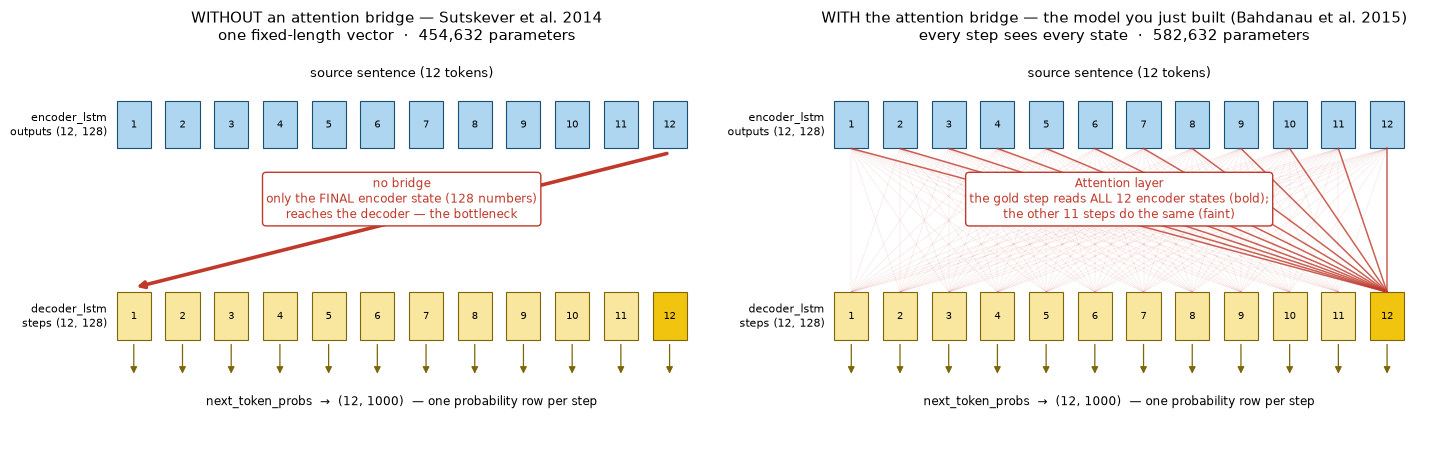

In [4]:
# WHAT: build the SAME model without the attention bridge, then draw both wirings.
# WHY: the difference between the two is one line of code and the entire history of
# neural machine translation. Every number in the picture is read off the real models.

import matplotlib.pyplot as plt

if HAS_TF:
    def build_seq2seq(with_attention, seed=0):
        """Identical encoder/decoder; the only difference is the attention bridge."""
        tf.keras.utils.set_random_seed(seed)          # matched weights for a fair comparison
        e_in = Input(shape=(max_len,), name="source_tokens")
        e_emb = Embedding(vocab_size, embedding_dim, name="source_embedding")(e_in)
        e_out, s_h, s_c = LSTM(hidden_units, return_sequences=True, return_state=True,
                               name="encoder_lstm")(e_emb)
        d_in = Input(shape=(max_len,), name="target_tokens")
        d_emb = Embedding(vocab_size, embedding_dim, name="target_embedding")(d_in)
        d_out, _, _ = LSTM(hidden_units, return_sequences=True, return_state=True,
                           name="decoder_lstm")(d_emb, initial_state=[s_h, s_c])
        if with_attention:
            ctx = Attention(name="attention")([d_out, e_out])       # reads ALL encoder states
            head = Concatenate(name="concat")([d_out, ctx])
        else:
            head = d_out                                            # only the final state got through
        out = Dense(vocab_size, activation="softmax", name="next_token_probs")(head)
        return Model([e_in, d_in], out)

    model_attention = build_seq2seq(True)
    model_plain = build_seq2seq(False)
    p_att = model_attention.count_params()
    p_no = model_plain.count_params()
    print(f"with attention: {p_att:,} parameters")
    print(f"without attention: {p_no:,} parameters   "
          f"(difference: {p_att - p_no:,}, which is the Dense head reading a wider vector)")

    # --- Draw the two wirings -------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
    specs = [(f"WITHOUT an attention bridge — Sutskever et al. 2014\n"
              f"one fixed-length vector  ·  {p_no:,} parameters", False),
             (f"WITH the attention bridge — the model you just built (Bahdanau et al. 2015)\n"
              f"every step sees every state  ·  {p_att:,} parameters", True)]
    for ax, (title, use_att) in zip(axes, specs):
        ax.set_xlim(-1.0, max_len - 0.2)
        ax.set_ylim(-1.15, 3.35)
        ax.axis("off")
        ax.set_title(title, fontsize=10.5)
        for j in range(max_len):
            ax.add_patch(plt.Rectangle((j - 0.35, 2.2), 0.7, 0.55,
                                       facecolor="#aed6f1", edgecolor="#1b4f72", lw=0.8))
            ax.text(j, 2.47, f"{j+1}", ha="center", va="center", fontsize=7)
            fc = "#f1c40f" if j == max_len - 1 else "#f9e79f"   # gold = the step we trace
            ax.add_patch(plt.Rectangle((j - 0.35, 0.0), 0.7, 0.55,
                                       facecolor=fc, edgecolor="#7d6608", lw=0.8))
            ax.text(j, 0.27, f"{j+1}", ha="center", va="center", fontsize=7)
            ax.annotate("", xy=(j, -0.42), xytext=(j, -0.02),
                        arrowprops=dict(arrowstyle="-|>", lw=0.9, color="#7d6608"))
        ax.text(-0.55, 2.47, f"encoder_lstm\noutputs ({max_len}, {hidden_units})",
                ha="right", va="center", fontsize=8)
        ax.text(-0.55, 0.27, f"decoder_lstm\nsteps ({max_len}, {hidden_units})",
                ha="right", va="center", fontsize=8)
        ax.text((max_len - 1) / 2, 3.02, f"source sentence ({max_len} tokens)",
                ha="center", fontsize=9)
        ax.text((max_len - 1) / 2, -0.75,
                f"next_token_probs  →  ({max_len}, {vocab_size})  — one probability row per step",
                ha="center", fontsize=8.5)
        if use_att:
            for j in range(max_len):                       # faint fan: the other decoder steps
                for k in range(max_len - 1):
                    ax.plot([j, k], [2.2, 0.55], color="#c0392b", lw=0.35, alpha=0.16, zorder=0)
            for j in range(max_len):                       # bold fan: the gold decoder step
                ax.plot([j, max_len - 1], [2.2, 0.55], color="#c0392b", lw=1.1, alpha=0.8, zorder=1)
            msg = (f"Attention layer\nthe gold step reads ALL {max_len} encoder states (bold);\n"
                   f"the other {max_len - 1} steps do the same (faint)")
        else:
            ax.annotate("", xy=(0, 0.6), xytext=(max_len - 1, 2.15),
                        arrowprops=dict(arrowstyle="-|>", lw=2.6, color="#c0392b"))
            msg = (f"no bridge\nonly the FINAL encoder state ({hidden_units} numbers)\n"
                   f"reaches the decoder — the bottleneck")
        ax.text((max_len - 1) / 2, 1.4, msg, ha="center", fontsize=8.8, color="#c0392b",
                bbox=dict(fc="white", ec="#c0392b", boxstyle="round,pad=0.3"))
    fig.tight_layout()
    plt.show()
else:
    print("TensorFlow unavailable — skipping the wiring diagram.")

**Read the picture.** Blue boxes are the 12 encoder outputs, gold-and-cream boxes the 12 decoder steps;
the layer names and the shapes `(12, 128)` and `(12, 1000)` are the ones printed in `model.summary()` above.

On the **left**, one thick red arrow: the decoder is handed the encoder's final state — 128 numbers — and
must write the whole translation from that. Every source word, however early, has to survive inside those
128 numbers. That single arrow is what Bahdanau, Cho & Bengio called *"a bottleneck"*.

On the **right**, the model you actually built. The bold red lines are the 12 connections from the gold
decoder step back to **all** 12 encoder states; the faint lines are the same fan for the other 11 steps —
144 direct paths instead of one. The cost of that is small and printed above: 128,000 extra parameters,
which is just the wider `Dense` head, on a 454,632-parameter base.

The picture makes the claim. The next cell measures whether the paths carry anything.

### Does the bridge actually change where information comes from?

A drawing can show that a path exists. To show that it *carries* something we ask the network a question it
cannot dodge: **when the decoder writes its last word, how much does that output depend on each source
token?** The derivative of the final-step output with respect to each source embedding answers exactly
that, and `tf.GradientTape` computes it for us.

Both models are built from the same seed, so the weights are matched and untrained. That is deliberate:
what we are measuring is the **architecture's information paths**, before any learning happens.

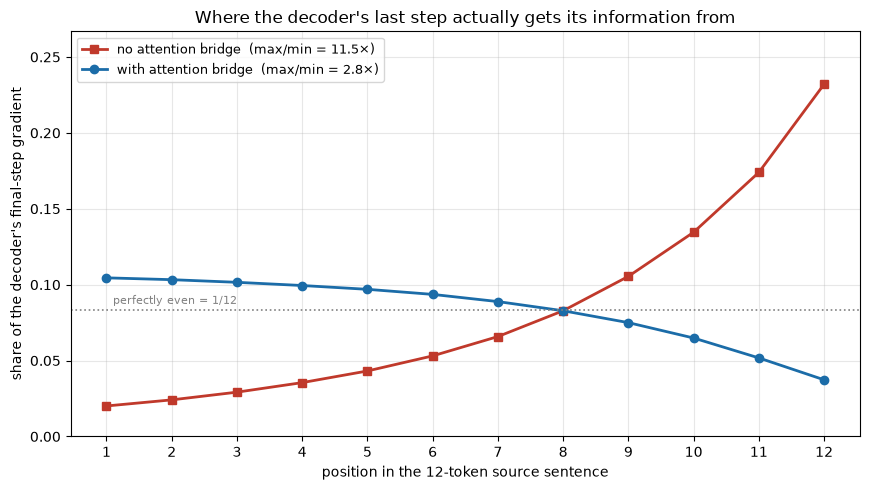

 source position   no attention   with attention
------------------------------------------------
               1          0.020            0.105
               2          0.024            0.103
               3          0.029            0.102
               4          0.035            0.099
               5          0.043            0.097
               6          0.053            0.094
               7          0.066            0.089
               8          0.083            0.083
               9          0.105            0.075
              10          0.135            0.065
              11          0.174            0.052
              12          0.232            0.037

First token's share:  without attention 0.020, with attention 0.105  (5.2× more)
Spread (largest share / smallest share):  without attention 11.5×, with attention 2.8×


In [5]:
# WHAT: gradient of the decoder's LAST step with respect to each source token's embedding.
# WHY: it converts "attention removes the bottleneck" from a quotation into a curve.
# Untrained weights on purpose — this is the wiring's reach, not learned behaviour.

if HAS_TF:
    probe_src = rng.integers(0, vocab_size, (4, max_len))     # 4 fake source sentences
    probe_tgt = rng.integers(0, vocab_size, (4, max_len))

    def source_sensitivity(m, has_attention):
        """Share of the final decoder step's gradient landing on each source position."""
        src_t = tf.constant(probe_src)
        tgt_t = tf.constant(probe_tgt)
        with tf.GradientTape() as tape:
            e = m.get_layer("source_embedding")(src_t)
            tape.watch(e)                                     # differentiate w.r.t. the source
            e_out, s_h, s_c = m.get_layer("encoder_lstm")(e)
            d_emb = m.get_layer("target_embedding")(tgt_t)
            d_out, _, _ = m.get_layer("decoder_lstm")(d_emb, initial_state=[s_h, s_c])
            if has_attention:
                head = tf.concat([d_out, m.get_layer("attention")([d_out, e_out])], axis=-1)
            else:
                head = d_out
            probs = m.get_layer("next_token_probs")(head)
            scalar = tf.reduce_sum(tf.reduce_max(probs[:, -1, :], axis=-1))   # last step only
        grad = tape.gradient(scalar, e)
        per_pos = np.abs(grad.numpy()).sum(axis=-1).mean(axis=0)
        return per_pos / per_pos.sum()                        # normalise to shares

    share_att = source_sensitivity(model_attention, True)
    share_no = source_sensitivity(model_plain, False)
    positions = np.arange(1, max_len + 1)

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    ax.plot(positions, share_no, marker="s", color="#c0392b", lw=2,
            label=f"no attention bridge  (max/min = {share_no.max()/share_no.min():.1f}×)")
    ax.plot(positions, share_att, marker="o", color="#1b6ca8", lw=2,
            label=f"with attention bridge  (max/min = {share_att.max()/share_att.min():.1f}×)")
    ax.axhline(1 / max_len, color="grey", ls=":", lw=1.2)
    ax.text(1.1, 1 / max_len + 0.004, f"perfectly even = 1/{max_len}", fontsize=8, color="grey")
    ax.set_xticks(positions)
    ax.set_xlabel("position in the 12-token source sentence")
    ax.set_ylabel("share of the decoder's final-step gradient")
    ax.set_title("Where the decoder's last step actually gets its information from")
    ax.set_ylim(0, max(share_no.max(), share_att.max()) * 1.15)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.show()

    print(f"{'source position':>16}{'no attention':>15}{'with attention':>17}")
    print("-" * 48)
    for j in range(max_len):
        print(f"{j+1:>16}{share_no[j]:>15.3f}{share_att[j]:>17.3f}")
    print(f"\nFirst token's share:  without attention {share_no[0]:.3f}, "
          f"with attention {share_att[0]:.3f}  "
          f"({share_att[0]/share_no[0]:.1f}× more)")
    print(f"Spread (largest share / smallest share):  "
          f"without attention {share_no.max()/share_no.min():.1f}×, "
          f"with attention {share_att.max()/share_att.min():.1f}×")
else:
    print("TensorFlow unavailable — skipping the sensitivity measurement.")

**Read the picture.** The dotted grey line is what a perfectly even model would look like: every source
position contributing 1/12 ≈ 0.083 of the gradient.

The **red curve (no bridge)** climbs steeply from left to right. The last source token gets roughly 0.23 of
the gradient; the first gets about 0.02 — an order of magnitude less. Read that in plain language: when the
bottleneck model writes its final word, the beginning of the source sentence is nearly invisible to it. The
information did not vanish because the model was badly trained — it was never trained. It is the shape of
the wiring, and it is the recency bias that made long sentences the failure case of 2014-era translation.

The **blue curve (with the bridge)** is almost flat, spanning under 3× from end to end instead of more than
11×, and the first token is now among the *best* served positions. That is not a coincidence: an early
source token feeds into every later encoder state, and with attention the decoder reads all of them
directly, so the early word arrives by twelve routes instead of one.

**What this does not show.** Both models are untrained, so neither curve says anything about translation
quality, and a flat gradient is not the same thing as a correct alignment. What it does establish is the
thing the architecture was designed to establish: the paths exist and they carry weight. Whether the model
learns to *use* them is a training question — and training is AIAT 122.

## 💬 Discuss

1. The 1954 demo translated 60 sentences and was reported as near-solved; ALPAC read the same field twelve
   years later and shut it down. Both judgements rested on real evidence. What should a 1954 evaluator have
   measured to avoid the mistake — and which of those measurements does your `model.summary()` above
   actually give you? (Careful: a correct architecture is not a working system.)
2. Machine translation makes two very different kinds of error: output that is obviously broken, and output
   that is **fluent, confident and wrong**. For a Saudi hospital translating discharge instructions into
   Urdu for a patient, which error is worse, and why? Does your answer change for translating tourist
   signage — and what does that tell you about "translation quality" as a single number?
3. Prates, Avelar & Lamb tested Google Translate across 12 gender-neutral languages and found "a strong
   tendency towards male defaults, in particular for fields linked to unbalanced gender distribution such
   as STEM jobs" ([arXiv:1809.02208](https://arxiv.org/abs/1809.02208)) — a gender-neutral *"they are an
   engineer"* comes back as *"he is an engineer"*. The model is reproducing its training corpus faithfully.
   Is that a bug to fix, a statistic to report, or a product decision to be made by someone else? Who
   should decide, and on what grounds?

## Summary

### What you actually did here
- Built a **real** Keras seq2seq model: embedding → encoder LSTM → decoder LSTM → attention → softmax output
- Read its `model.summary()` — note where the `attention` layer sits, connecting decoder steps to **all** encoder states
- Ran an end-to-end forward pass and verified the output shape `(batch, steps, vocabulary)`

### Key Concepts
1. **Seq2Seq architecture**: encoder compresses the source; decoder generates the target
2. **Attention**: at every decoding step, the decoder looks back over all encoder hidden states and takes a
   weighted average (the same mechanism you computed by hand in `01_attention_transformers_bridge.ipynb`) —
   this removes the single-context-vector bottleneck and dramatically improves long-sentence translation
3. **What training would need** (not done here): a parallel corpus of aligned sentence pairs, teacher
   forcing, and substantial compute — training mechanics arrive in **AIAT 122 (Course 08)**

### Where this architecture went
Replace the LSTMs with self-attention layers and this encoder–decoder-with-attention design becomes the
**Transformer** ("Attention Is All You Need", 2017) — the architecture behind BERT (previous notebook) and
GPT (next notebook).

**Reference:** Course 07, Unit 4: "Deep Learning for NLP" — seq2seq with attention practical content


## ⚠️ Where this breaks

**This notebook built an architecture, not a translator.** Vocabulary 1,000, sequence length 12, weights
random: the forward pass proves the wiring is correct, and every probability it printed is noise by
construction. Do not quote a single number from this run as evidence of translation quality — that is the
1954 mistake in miniature.

**What a working version would actually cost:** a *parallel corpus* of hundreds of thousands to millions of
aligned sentence pairs; teacher forcing during training; a real 30k+ subword vocabulary (Unit 2); beam
search at inference; days of GPU time; and BLEU or COMET evaluation against human references. None of that
is optional, and for most language pairs the corpus is the hard part.

**Where this architecture is now the wrong choice.** The recurrent encoder–decoder was superseded in 2017:
replace the LSTMs with self-attention and you have the Transformer
([arXiv:1706.03762](https://arxiv.org/abs/1706.03762)) — same encoder–decoder shape, trains in parallel,
much better on long sentences. Build this one to understand it; ship the other one.

**Where machine translation itself breaks, whatever the architecture:**
- **Low-resource and dialectal pairs.** Modern Standard Arabic ↔ English is well served; Saudi and Gulf
  dialects and code-switched Arabic-English are far thinner in every public corpus. These gaps are
  documented rather than anecdotal — see the Absher Saudi-dialect benchmark
  ([arXiv:2507.10216](https://arxiv.org/abs/2507.10216)) and the survey of Arabic benchmarks and their
  blind spots ([arXiv:2510.13430](https://arxiv.org/abs/2510.13430)).
- **Names, numbers, units, dosages and negation** — the parts a reader most needs to be exact are precisely
  the parts a fluent model is most willing to paraphrase.
- **High-stakes text.** Legal, medical and safety content needs a human translator in the loop; MT there is
  a drafting aid, never the deliverable.

**The cheaper alternative:** for a fixed set of phrases — UI strings, signage, form labels, standard replies
— a human-written phrase table is exact, auditable and free at runtime. Do not train a translator to render
40 menu items.

## 📚 References

The machine-translation lineage this notebook builds on, and where translation quality is produced in 2026:

1. Sutskever, I., Vinyals, O., & Le, Q. V. (2014). *Sequence to Sequence Learning with Neural Networks*. NeurIPS 2014. [arXiv:1409.3215](https://arxiv.org/abs/1409.3215)
2. Cho, K., van Merrienboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation*. EMNLP 2014. [arXiv:1406.1078](https://arxiv.org/abs/1406.1078)
3. Bahdanau, D., Cho, K., & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR 2015. [arXiv:1409.0473](https://arxiv.org/abs/1409.0473)
4. NLLB Team et al. (2022). *No Language Left Behind: Scaling Human-Centered Machine Translation*. [arXiv:2207.04672](https://arxiv.org/abs/2207.04672)
5. Bari, M. S., Alnumay, Y., Alzahrani, N. A., Alotaibi, N. M., Alyahya, H. A., et al. (2024). *ALLaM: Large Language Models for Arabic and English*. [arXiv:2407.15390](https://arxiv.org/abs/2407.15390) — bilingual training aimed at transferring between Arabic and English without degrading either.
6. Yang, A., Li, A., Yang, B., Zhang, B., Hui, B., et al. (2025). *Qwen3 Technical Report*. [arXiv:2505.09388](https://arxiv.org/abs/2505.09388) — a general open model family covering 119 stated languages; translation as one capability among many rather than a dedicated architecture.
